In [1]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path
import json
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/train-test.csv")
df['date'] = pd.to_datetime(df['date'])
df.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [3]:
df = df.sort_values(by = 'date')

# Preprocessing

In [4]:
df['load_id'].nunique(), df.shape[0]

(48000, 48000)

In [5]:
df.dtypes

load_id                 object
pickup                  object
delivery                object
pickup_lat             float64
pickup_lon             float64
delivery_lat           float64
delivery_lon           float64
distance               float64
equipment               object
weight                 float64
date            datetime64[ns]
market_index           float64
quote_signal           float64
posted_rate            float64
dtype: object

In [6]:
df.isna().mean()

load_id         0.000000
pickup          0.000000
delivery        0.000000
pickup_lat      0.000000
pickup_lon      0.000000
delivery_lat    0.000000
delivery_lon    0.000000
distance        0.000000
equipment       0.000000
weight          0.006250
date            0.000000
market_index    0.007792
quote_signal    0.000000
posted_rate     0.000000
dtype: float64

In [7]:
# check distributions of numeric features
df[df.columns[df.dtypes != 'object'].tolist()].describe(percentiles = np.arange(0, 1, 0.1))

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,date,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,48000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,2025-05-31 19:53:29.400000,1.083387,2.062468,2373.980682
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,2025-01-01 00:00:00,0.676390,0.692280,57.220000
0%,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,2025-01-01 00:00:00,0.676390,0.692280,57.220000
10%,29.875340,-115.877250,29.875340,-115.877250,328.200000,20831.800000,2025-01-31 00:00:00,0.871440,1.735059,802.597000
20%,31.804420,-99.854560,31.804420,-99.854560,476.100000,24444.800000,2025-03-03 00:00:00,0.925710,1.850590,1110.120000
30%,33.079210,-94.383430,33.079210,-94.383430,635.800000,27033.000000,2025-04-01 00:00:00,0.971140,1.928127,1411.462000
40%,34.153340,-89.855880,34.153340,-89.855880,789.000000,29311.600000,2025-05-01 00:00:00,1.012920,1.994312,1715.356000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,2025-05-31 00:00:00,1.055800,2.055750,2030.760000
60%,36.991520,-86.289400,36.991520,-86.289400,1151.040000,33545.000000,2025-06-30 00:00:00,1.120630,2.118462,2423.530000


In [8]:
# check if there any city with muplitple coords

for col in ["pickup", "delivery"]:
    check = df.groupby(col).agg(lat_n = (f"{col}_lat", "nunique"), lon_n = (f"{col}_lon", "nunique"))
    bad_cities = check[(check["lat_n"] > 1) | (check["lon_n"] > 1)]
    if not bad_cities.empty:
        raise ValueError(f"{col} cities with multiple coords:\n{bad_cities}")

In [9]:
# check if same pickup and delivery cities have different coords

pickup_coords = df[["pickup", "pickup_lat", "pickup_lon"]].rename(columns={"pickup": "city", "pickup_lat": "lat", "pickup_lon": "lon"})
delivery_coords = df[["delivery", "delivery_lat", "delivery_lon"]].rename(columns={"delivery": "city", "delivery_lat": "lat", "delivery_lon": "lon"})

all_coords = pd.concat([pickup_coords, delivery_coords], ignore_index=True)

city_coord_counts = all_coords.drop_duplicates().groupby("city").size()
problem_cities = city_coord_counts[city_coord_counts > 1]

if len(problem_cities) > 0:
    raise ValueError("pickup and delivery the same cities have different coords")

In [10]:
print("Distribution of features where initial weight value is negetive")
display(df.loc[df["weight"] < 0, ["weight", "distance", "equipment", "market_index", "posted_rate"]].assign(weight=lambda x: x["weight"].abs()).describe(percentiles=np.arange(0, 1, 0.1)))
print()
print("Distribution of features where initial weight value is positive")
display(df.loc[df["weight"] > 0, ["weight", "distance", "equipment", "market_index", "posted_rate"]].describe(percentiles=np.arange(0, 1, 0.1)))


Distribution of features where initial weight value is negetive


,weight,distance,market_index,posted_rate
count,292.000000,292.000000,289.000000,292.000000
mean,31724.195205,1120.920205,1.096322,2389.786233
std,8262.536326,733.132047,0.171562,1641.761285
min,5000.000000,75.100000,0.789880,247.370000
0%,5000.000000,75.100000,0.789880,247.370000
10%,21273.400000,308.900000,0.874046,760.630000
20%,24423.800000,483.080000,0.945242,1121.650000
30%,26959.000000,641.390000,0.981550,1403.806000
40%,29695.200000,777.900000,1.025016,1658.050000
50%,31821.500000,930.450000,1.065710,1994.960000



Distribution of features where initial weight value is positive


,weight,distance,market_index,posted_rate
count,47408.000000,47408.000000,47038.000000,47408.000000
mean,31415.358674,1135.887743,1.083445,2374.030869
std,7994.902979,728.495026,0.168049,1486.103110
min,5000.000000,70.000000,0.676390,57.220000
0%,5000.000000,70.000000,0.676390,57.220000
10%,21090.400000,328.170000,0.871557,802.561000
20%,24591.000000,476.000000,0.925868,1110.152000
30%,27131.000000,635.800000,0.971250,1411.879000
40%,29379.800000,789.100000,1.012960,1716.056000
50%,31493.500000,953.400000,1.055890,2031.440000


In [11]:
print(f"Fraction of negative values for weight feature: {np.round(df[df['weight'] < 0].shape[0] / df.shape[0], 3)}")

# convert neg values into pos ones
df["weight"] = df["weight"].abs()

Fraction of negative values for weight feature: 0.006


# Feature Engineering

In [12]:
def add_distance_features(df):
   """Add distance and date features."""
   # distance features
   df["distance_sq"] = df["distance"] ** 2
   df["sqrt_distance"] = np.sqrt(df["distance"])
   df["weight_per_mile"] = df["weight"] / df["distance"]
   
   # date features
   df["dayofweek"] = df["date"].dt.dayofweek
   df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
   df["day"] = df["date"].dt.day
   
   
   return df

df = add_distance_features(df)

# Modeling

In [13]:
target = "posted_rate"

cat_features = ['equipment']

features = [
    'distance',
    'distance_sq',
    'sqrt_distance',
    'weight',
    'weight_per_mile',
    'equipment',
    'dayofweek',
    'is_weekend',
    'day'
]


X_train = df[df['date'] < "2025-10-01"][features]
y_train = np.log1p(df[df['date'] < "2025-10-01"][target])

X_test = df[df['date'] >= "2025-10-01"][features]
y_test = df[df['date'] >= "2025-10-01"][target]


In [14]:
def calculate_metrics(y_true, y_pred):
    ''' Function to calculate regression metrics
        Parameters:
            y_true: actual target
            y_pred: predicted target
    '''
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2":   r2_score(y_true, y_pred),
        "MAPE": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
    }

In [15]:
# TimeSeries Cross-Validation
n_splits = 6
random_seed = 42
tscv = TimeSeriesSplit(n_splits=n_splits)

cv_results = []
best_iters = []

catboost_params = dict(
    iterations=1500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=5,
    loss_function="RMSE",
    eval_metric="RMSE",
    od_type="Iter",
    od_wait=100,
    random_seed=random_seed,
    verbose=100,
)


for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    X_tr, y_tr = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
    X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]

    train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
    valid_pool = Pool(X_val, y_val, cat_features=cat_features)

    model = CatBoostRegressor(**catboost_params)
    model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

    pred_log = model.predict(valid_pool)
    # predictions in original scale
    pred = np.expm1(pred_log)
    y_true = np.round(np.expm1(y_val), 2)

    metrics = calculate_metrics(y_true, pred)
    metrics.update({
        "fold": fold,
        "n_train": len(tr_idx),
        "n_valid": len(val_idx),
        "best_iter": model.get_best_iteration(),
    })
    cv_results.append(metrics)
    best_iters.append(model.get_best_iteration())

    print(f"Fold {fold} | MAE: {metrics['MAE']:.2f} | best_iter: {metrics['best_iter']}")

cv_results = pd.DataFrame(cv_results)
print("\n=== CV Summary ===")
print(cv_results[["MAE", "RMSE", "R2", "MAPE"]].describe().round(2))
print(f"\nMean best_iteration: {np.mean(best_iters):.0f}")

0:	learn: 0.6317170	test: 0.6324580	best: 0.6324580 (0)	total: 57.6ms	remaining: 1m 26s
100:	learn: 0.1595994	test: 0.1577828	best: 0.1577828 (100)	total: 254ms	remaining: 3.52s
200:	learn: 0.1563209	test: 0.1569538	best: 0.1569323 (194)	total: 427ms	remaining: 2.76s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.1569322881
bestIteration = 194

Shrink model to first 195 iterations.
Fold 1 | MAE: 123.14 | best_iter: 194
0:	learn: 0.6317778	test: 0.6331629	best: 0.6331629 (0)	total: 3.4ms	remaining: 5.09s
100:	learn: 0.1581422	test: 0.1520847	best: 0.1520847 (100)	total: 278ms	remaining: 3.85s
200:	learn: 0.1558265	test: 0.1519968	best: 0.1517739 (146)	total: 534ms	remaining: 3.45s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.1517738857
bestIteration = 146

Shrink model to first 147 iterations.
Fold 2 | MAE: 154.55 | best_iter: 146
0:	learn: 0.6322790	test: 0.6402636	best: 0.6402636 (0)	total: 3.58ms	remaining: 5.36s
100:	learn: 0.1554248	tes

In [16]:
cv_results

,MAE,RMSE,R2,MAPE,fold,n_train,n_valid,best_iter
0,123.135027,530.313751,0.857340,5.689048,1,6169,6163,194
1,154.549684,529.111963,0.869927,6.685045,2,12332,6163,146
2,165.780686,561.685900,0.855413,7.654049,3,18495,6163,154
3,202.077972,697.682471,0.802274,7.586680,4,24658,6163,217
4,118.950464,646.874969,0.813704,5.149851,5,30821,6163,203
5,113.136944,624.967389,0.830999,5.022862,6,36984,6163,248


In [17]:
# Train final model
final_iterations = int(np.mean(best_iters))

final_params = dict(
    iterations=final_iterations,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=5,
    loss_function="RMSE",
    random_seed=random_seed,
    verbose=100,
)

print(f"Training final model with {final_iterations} iterations...")

full_pool = Pool(X_train, y_train, cat_features=cat_features)
final_model = CatBoostRegressor(**final_params)
final_model.fit(full_pool)

Training final model with 193 iterations...
0:	learn: 0.6350388	total: 4.53ms	remaining: 870ms
100:	learn: 0.1569738	total: 324ms	remaining: 296ms
192:	learn: 0.1557173	total: 623ms	remaining: 0us


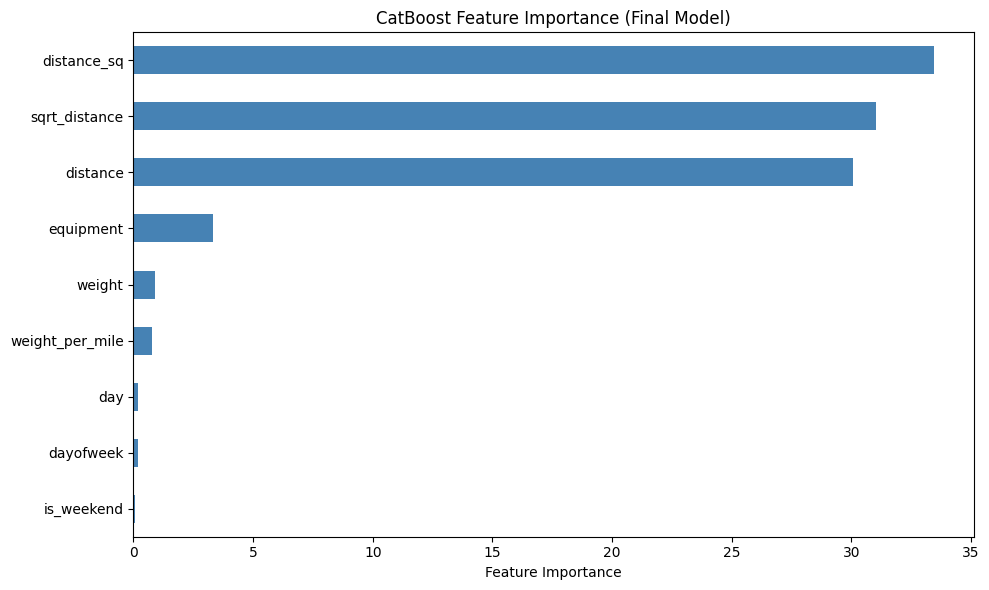

In [19]:
# Feature Importance
feature_importances = final_model.get_feature_importance(full_pool)
fi = pd.Series(feature_importances, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
fi.plot(kind="barh", color="steelblue")
plt.xlabel("Feature Importance")
plt.title("CatBoost Feature Importance (Final Model)")
plt.tight_layout()
plt.show()

In [20]:
test_pool = Pool(X_test, cat_features=cat_features)
pred_test_log = final_model.predict(test_pool)
pred_test = np.round(np.expm1(pred_test_log), 2)

holdout_metrics = calculate_metrics(y_test, pred_test)
print("=== Hold-out (Oct) ===")
for k, v in holdout_metrics.items():
    print(f"{k}: {v:.2f}")

=== Hold-out (Oct) ===
MAE: 120.18
RMSE: 650.77
R2: 0.82
MAPE: 5.78


In [21]:
models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)
model_path = models_dir / "final_model.cbm"
final_model.save_model(str(model_path))

print("Final model saved")

meta = {
    "final_iterations": final_iterations,
    "seeds": random_seed,
    "cat_features": cat_features,
    "catboost_parameters": {
        k: (str(v) if not isinstance(v, (int, float, str, bool, type(None))) else v)
        for k, v in final_params.items()
    }
}

meta_path = models_dir / "training_meta.json"
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2, default=str)
print("Final metadata saved")

Final model saved
Final metadata saved


# Applying

In [22]:
# list of features used for training model 
feature_names = final_model.feature_names_

In [23]:
validation_df = pd.read_csv("data/validation.csv")
valid_template = pd.read_csv("data/validation-predictions-template.csv")
validation_df['date'] = pd.to_datetime(validation_df['date'])

# preproc + feature engineering
validation_df["weight"] = validation_df["weight"].abs()
validation_df = add_distance_features(validation_df)

# check all model features exist in validation_df
missing = [f for f in feature_names if f not in validation_df.columns]
if missing:
    raise ValueError(f"Missing features in validation_df: {missing}")

# make predictions
validation_df["predicted_rate"] = np.round(np.expm1(final_model.predict(validation_df[feature_names])), 2)
valid_template["predicted_rate"] = validation_df["predicted_rate"].values

# save result
valid_template.to_csv("validation_predictions.csv", index=False)

In [24]:
december = pd.read_csv("data/december_chart_inputs.csv")
december["date"] = pd.to_datetime(december["date"])

# preproc + feature engineering
december["weight"] = december["weight"].abs()
december = add_distance_features(december)

feature_names = final_model.feature_names_

# check all model features exist in validation_df
missing = [f for f in feature_names if f not in december.columns]
if missing:
    raise ValueError(f"Missing features: {missing}")

december["predicted_rate"] = np.round(np.expm1(final_model.predict(december[feature_names])), 2)

# keep required columns & order
out = december[["pickup", "delivery", "distance", "equipment", "weight", "date", "predicted_rate"]]

# overwrite the same file
out.to_csv("data/december_chart_inputs.csv", index=False)